<a href="https://colab.research.google.com/github/anyuanay/INFO323/blob/main/INFO323_Lecture_week4_GCP_BigQuery_AI_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="text-align:center"> INFO 323: Cloud Computing and Big Data</h1>
<h2 style="text-align:center"> College of Computing and Informatics</h2>
<h2 style="text-align:center">Drexel University</h2>

<h3 style="text-align:center"> Exploratory Data Analysis using BigQuery on Flights Data</h3>
<h3 style="text-align:center"> Yuan An, PhD</h3>
<h3 style="text-align:center">Associate Professor</h3>

Reference: Data Science on the Google Cloud Platform. Valliappa Lakshmanan. O'Reilly, 2ed, April 2022

Ch5. Interactive Data Exploration

# Retrieval Practice (Week3-Quiz2)

## Data Ingest:
### You should have downloaded and ingested the flight data of a year to BigQuery
### Ensure to use the table name you created.
### In my case, the table name is \`dsongcp.flights-2023\`.
### NOTE: If your dataset name contains "-", you may need use backtick \`\` in the SQL statement to refer to the dataset.

## Access BigQuery from Notebook: BigQuery Client Library

- The standard programmatic approach for data science.
- Best for: Complex pipelines and dynamic queries.
- Authenticates using google.colab.auth.
- Returns results directly as a Pandas DataFrame.

## Alternatively, BigQuery Magics

- Quick, SQL-centric approach with minimal Python code.
- Best for: Fast data exploration and pure SQL testing.
- Uses the %%bigquery cell magic to store data in a variable.
- Very readable and beginner-friendly.

For example, you can run a query on your BigQuery table using the `%%bigquery` magic environment that comes with Vertex AI Workbench:

```
%%bigquery
SELECT
  COUNTIF(ArrDelay >= 15)/COUNT(ArrDelay) AS frac_delayed
FROM dsongcp.flights_raw
```

## Vertex AI Workbench
GCP Vertex AI workbench provides a hosted version of JupyterLab on Google Cloud; it knows how to authenticate against Google Cloud so as to provide easy access to Cloud Storage, BigQuery, Cloud Dataflow, Vertex AI Training, and so on.


## Colab vs. Vertext AI
| Feature | Google Colab (Free/Pro) | Vertex AI Notebooks (Workbench) |
| :--- | :--- | :--- |
| **Primary Goal** | Education, quick prototyping, and sharing. | Production ML, data engineering, and MLOps. |
| **Infrastructure** | **Transient:** VMs are temporary; storage wipes when the session ends. | **Permanent:** Managed instances; environment and files are saved like a real PC. |
| **Customization** | **Limited:** Pre-configured environment provided by Google. | **Full Control:** Root access to OS; support for custom Docker and hardware. |
| **Security** | **Standard:** Uses Google Drive permissions and personal accounts. | **Enterprise:** Integrated with Google Cloud IAM for granular access control. |
| **BigQuery Tools** | **Client Libraries:** Requires Python code or basic UI pop-ups to query data. | **Native Integration:** Built-in BigQuery Explorer and dedicated SQL cells. |

## When should you switch to Vertext AI?

- Think of Colab as a "Google Doc for Code" and Vertex AI Notebooks as a "Professional Cloud Workstation.”
- For a college student or a solo researcher, Colab is more than enough.
- Massive Datasets: If you need to process data that is too big for Colab’s RAM, switch to Vertex AI.
- The "BigQuery Pane": Vertex AI has a built-in "Explorer" (similar to the BigQuery console) inside the notebook. You can browse tables, preview schemas, and even write SQL in a dedicated window without leaving your code.
- Automation: If you want your notebook to run every Monday at 8:00 AM to update a dashboard, Vertex AI has "Scheduled Notebooks." Colab (mostly) requires you to keep the tab open.
- Version Control: Vertex AI integrates directly with GitHub, making it easier to work on a team than sharing a file via Google Drive.

## The Business Problem

**The scenario:**

- You are about to take a flight and, just before the flight takes off from the runway (and you are asked to switch off your phone), you have the opportunity to send one last text message.
- It is past the published departure time and you are a bit anxious.
- You have scheduled an important meeting with a client at its offices.
- You need to decide whether to cancel the meeting or not.

**Should I cancel my meeting with a client in the city I am flying to?**

- Will my flight be on-time? i.e., Will the flight arrive within 15 minutes of the scheduled arrival time?
- What is the probability of that the flight is on-time?
- To cancel the meeting: if the probability of on-time is less than 70% (the probability of being late is more than 30%.).

**Use CDF for decision making**

- Cancel the meeting if CDF(15 minutes) < 0.7 (We want to be at least 70% sure of arriving within 15 minutes of the expected time).

**Explore a simple decision rule:**
- Use the departure delay to predict the probability of (not) on-time.
- Answer the following simple question: at which departure delay, the flight will have more than 30% of chance to be later 15 minutes more than the published arrival time.

## SQL Basics

Here are some fundamental SQL operations:

- SELECT Statement: Used to retrieve data from a database.
    * $\texttt{SELECT column1, column2 FROM table_name}$

- WHERE Clause: Filters data based on conditions.
    * $\texttt{SELECT * FROM table_name WHERE condition}$

- ORDER BY: Sorts data in ascending (ASC) or descending (DESC) order.
    * $\texttt{SELECT column1, column2 FROM table_name ORDER BY column1 ASC}$

- LIMIT: Limits the number of rows returned.
    * $\texttt{SELECT * FROM table_name LIMIT 5}$

- The WHERE clause helps you filter data based on a condition:

    * $\texttt{SELECT * FROM employees WHERE salary > 50000}$

    * You can use comparison operators like:
        - '=': Equal to
        - '>': Greater than
        - '<': Less than
        - 'LIKE': For pattern matching

- SQL provides functions to summarize or aggregate data:
    * COUNT(): Counts the number of rows.

        * $\texttt{SELECT COUNT(*) FROM table_name}$

    * SUM(): Adds up values in a column.

        * $\texttt{SELECT SUM(salary) FROM employees}$

    * AVG(): Calculates the average value.

        * $\texttt{SELECT AVG(salary) FROM employees}$

- GROUP BY: Groups rows that have the same values into summary rows.

    \begin{array}{l}
    \texttt{SELECT department, AVG(salary)} \\
    \texttt{FROM employees}\\
    \texttt{GROUP BY department}\\
    \end{array}
    
- HAVING: Filters groups based on aggregate conditions (used with GROUP BY).

    
    \begin{array}{l}
    \texttt{SELECT department, AVG(salary)} \\
    \texttt{FROM employees}\\
    \texttt{GROUP BY department}\\
    \texttt{HAVING AVG(salary) > 3000}
    \end{array}
    


- Joins combine data from two or more tables:
    * INNER JOIN: Retrieves records with matching values in both tables.

    
    \begin{array}{l}
    \texttt{SELECT employees.name, departments.department} \\
    \texttt{FROM employees} \\
    \texttt{INNER JOIN departments} \\
    \texttt{ON employees.department_id = departments.id}
    \end{array}
    

    * LEFT JOIN: Retrieves all records from the left table and matched records from the right table.

    
    \begin{array}{l}
    \texttt{SELECT employees.name, departments.department} \\
    \texttt{FROM employees} \\
    \texttt{LFFT JOIN departments} \\
    \texttt{ON employees.department_id = departments.id} \\
    \end{array}
    

![](https://i.imgur.com/KCUdbZe.png)

## Using Colab, you need to authenticate

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


## Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from google.cloud import bigquery

## Initialize the Client

In [ ]:
# Initialize the client
# project_id = 'YOUR PROJECT ID'

project_id = 'info323-spring2026-ya45' # this is my project id, not yours

bq = bigquery.Client(project=project_id)

In [ ]:
# if open the notebook from Vertex AI instance
# bq = bigquery.Client()

# EDA Objectives for Developing a Predictive Model
The following exploratory data analysis (EDA) aims to identify the key drivers of flight delays and establish a simple model with strong explanatory power:
## 1. Scope and Scale
- Identify and catalog all unique origin and destination airports within the dataset to understand the network's breadth.
## 2. Delay Distribution and Statistical Profiling
- Analyze the overall distribution of departure and arrival delays.
- Compare the arrival delay profiles of on-time versus delayed flights to identify significant statistical variances
- Examine the distribution of arrival delays specifically for flights that exceed a 10-minute threshold.
## 3. Airport Performance Metrics
- Calculate the average departure and arrival delays per airport.
- Determine if specific airports exhibit unique delay patterns that warrant targeted modeling.
- Quantify the total percentage of delayed flights across the entire dataset.
## 4. Predictive Correlation and Probability
- Map the relationship between departure delays and their resulting arrival delays.
    - Distribution Analysis: For any given departure delay, how are the subsequent arrival delays distributed?
    - Inference: At what departure delay interval can we predict a specific arrival delay with $> 70\%$ probability?
    - Risk Threshold: Determine the specific departure delay "tipping point" beyond which a flight has a $> 70\%$ chance of being late.
## 5. Model Validation
- Assess the performance of the resulting simple model
- Validate the model’s robustness and generalizability by testing it against out-of-sample data from a different year.

## Scope and Scale: List the Origin and Desitnation Airports and Number of Flights
- list the unique origin airports and number of flights
- list the unique destination airports and number of flights.

In [ ]:
sql = """
SELECT
  Origin,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by Origin
Order by num_flights desc
"""

df = bq.query(sql).to_dataframe()
print(df)

    Origin  num_flights
0      ATL       336463
1      DEN       288985
2      DFW       285244
3      ORD       258867
4      CLT       195100
..     ...          ...
345    ALO           75
346    OWB           43
347    COD           35
348    PUB           27
349    PHF            2

[350 rows x 2 columns]


In [ ]:
df.shape

(350, 2)

In [ ]:
(df.num_flights < 3650).sum()

np.int64(198)

## How are the arrival deplays distributed over the year?
Find the arrival delay for flights that depart more than 10 minutes late. If we put the results in a Pandas DataFrame, we can get the basis statistics using Pandas DataFrame describe().

In [ ]:
sql = """
SELECT
  arrdelay
FROM `dsongcp.flights-2023`
Where depdelay > 10
"""

df = bq.query(sql).to_dataframe()

In [ ]:
df.shape

(1604247, 1)

In [ ]:
df.describe()

,arrdelay
count,1.595610e+06
mean,5.692355e+01
std,9.914236e+01
min,-8.100000e+01
25%,1.200000e+01
50%,3.000000e+01
75%,6.700000e+01
max,4.405000e+03


## Let us visualize the ArrDelays for DepDelay > 10 minutes
- Plot a violin plot of the arrival delay for flights that depart more than 10 minutes late.
- What does the violin plot tell us?

<Axes: xlabel='arrdelay'>

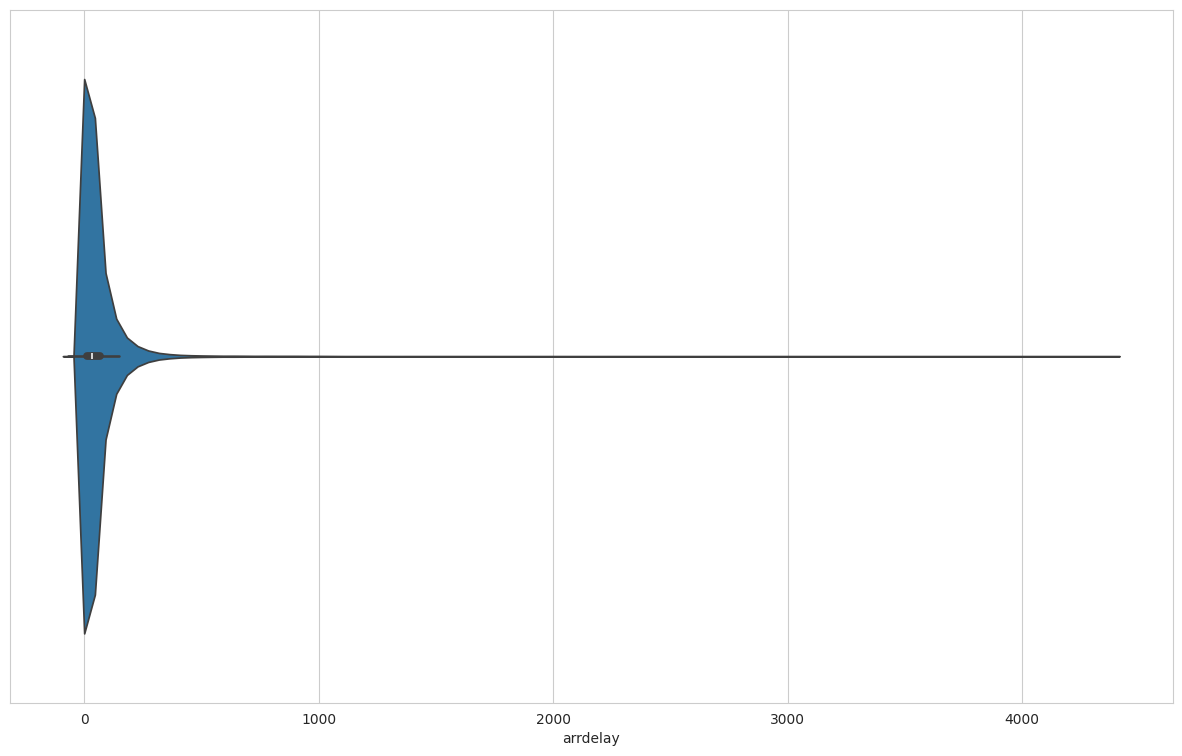

In [ ]:
plt.figure(figsize=(15, 9))
sns.set_style("whitegrid")
sns.violinplot(data=df, x="arrdelay", inner='box', orient='landscape')

## What are the average departure and arrival delay at each (origin) airport?
Find average departure and arrival delays at each airport (origin) in the US.

In [ ]:
sql = """
SELECT
  origin,
  avg(DepDelay) as avg_depdelay,
  avg(ArrDelay) as avg_arrdelay,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by origin
order by avg_depdelay desc
"""

df = bq.query(sql).to_dataframe()

In [ ]:
df.shape

(350, 4)

In [ ]:
df.head()

,origin,avg_depdelay,avg_arrdelay,num_flights
0,SMX,61.537736,67.132075,107
1,COD,46.969697,41.515152,35
2,PPG,37.338710,36.556452,124
3,HTS,33.896985,32.246851,402
4,BIH,31.144033,16.759336,257


<Axes: ylabel='Frequency'>

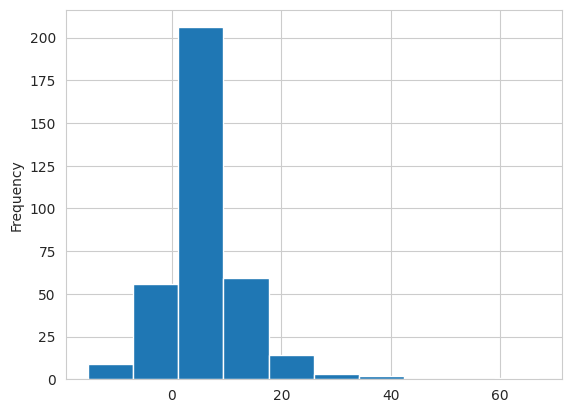

In [ ]:
# Plot the average arrdelay in histogram
df.avg_arrdelay.plot.hist()

We will retain only airports where there were at least 365 flights (at least 1 flights per day), and sort them by departure delay in descending order.

In [ ]:
sql = """
SELECT
  origin,
  avg(DepDelay) as avg_depdelay,
  avg(ArrDelay) as avg_arrdelay,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by origin
Having num_flights > 365
order by avg_depdelay desc
"""

df = bq.query(sql).to_dataframe()

In [ ]:
df.shape

(324, 4)

In [ ]:
df.head()

,origin,avg_depdelay,avg_arrdelay,num_flights
0,HTS,33.896985,32.246851,402
1,USA,29.997337,28.873333,764
2,DEC,28.710445,23.375519,986
3,CIU,28.675105,17.180282,725
4,MVY,28.012750,22.376838,1158


## What is the percentage of delayed flights?
Assume a flight is delayed if its arrival delay was more than 15 minutes. Find the percentage of the delayed flights.

In [ ]:
sql = '''
Select countif(arrdelay > 15) / count(arrdelay) as frac_delayed
FROM `dsongcp.flights-2023`
'''

bq.query(sql).to_dataframe()

,frac_delayed
0,0.198665


## Which origin airport has the most number of delayed flights?
For each origin airport, calculate and order the percentage of delayed flights.

In [ ]:
sql = """
SELECT
  origin,
  countif(arrdelay > 15) / count(arrdelay) as frac_delayed,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by origin
Having num_flights > 365
order by frac_delayed desc
"""

df = bq.query(sql).to_dataframe()

In [ ]:
df.head()

,origin,frac_delayed,num_flights
0,SCK,0.463415,536
1,HTS,0.375315,402
2,BET,0.347578,722
3,USA,0.338667,764
4,BQN,0.326264,2898


Stockton Metropolitan Airport and Tri-State Airport is a public airport in Wayne County, West Virginia are the top 2. Do they have flights all-year around?

In [ ]:
sql = """
SELECT
  Origin,
  Month,
  count(*) as num_flights_month
FROM `dsongcp.flights-2023`
Where origin ='SCK' or origin='HTS'
Group by Origin, Month
order by num_flights_month desc
"""
df = bq.query(sql).to_dataframe()

In [ ]:
df.shape

(24, 3)

In [ ]:
df

,Origin,Month,num_flights_month
0,HTS,7,74
1,HTS,6,69
2,SCK,10,53
3,SCK,3,50
4,SCK,7,49
5,SCK,6,48
6,SCK,1,46
7,SCK,12,44
8,HTS,8,43
9,SCK,11,43


<Axes: xlabel='Month'>

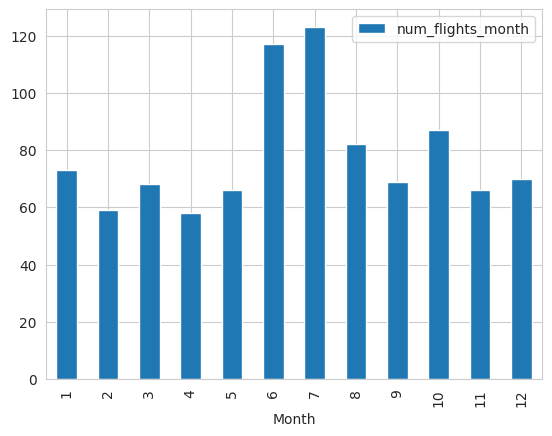

In [ ]:
df[['Month', 'num_flights_month']].groupby('Month').sum().plot.bar()

## Which pair of origin and destination airports has the most number of delayed flights?
For each pair of origin and destination airports, calculate and order the percentage of delayed flights.

In [ ]:
sql = """
SELECT
  origin,
  dest,
  countif(arrdelay > 15) / count(arrdelay) as frac_delayed,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by origin, dest
Having num_flights > 365
order by frac_delayed desc
"""
df = bq.query(sql).to_dataframe()

In [ ]:
df.head()

,origin,dest,frac_delayed,num_flights
0,BDL,SJU,0.467520,1035
1,RIC,MCO,0.459524,866
2,FLL,LAS,0.455367,906
3,SCK,LAS,0.453488,432
4,FLL,RIC,0.447075,733


## How many pairs of airports having frac_delayed > 30%?

In [ ]:
df[df.frac_delayed > 0.3]

,origin,dest,frac_delayed,num_flights
0,BDL,SJU,0.467520,1035
1,RIC,MCO,0.459524,866
2,FLL,LAS,0.455367,906
3,SCK,LAS,0.453488,432
4,FLL,RIC,0.447075,733
...,...,...,...,...
163,DEN,FLL,0.300712,1718
164,DFW,SMF,0.300665,1682
165,DFW,SAN,0.300578,3515
166,MCO,PHX,0.300518,1760


## Which airline has the most delayed flights?

In [ ]:
sql = """
SELECT
  Reporting_airline,
  countif(arrdelay > 15) / count(*) as frac_delayed,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by Reporting_airline
Having num_flights > 365
order by frac_delayed desc
"""
df = bq.query(sql).to_dataframe()

In [ ]:
df.head()

,Reporting_airline,frac_delayed,num_flights
0,F9,0.299304,177542
1,B6,0.297247,274852
2,NK,0.277927,263871
3,G4,0.248643,115539
4,HA,0.223721,80967


## Do airlines perform differently for different origins and destinations?

In [ ]:
sql = """
SELECT
  Reporting_airline,
  Origin,
  Dest,
  countif(arrdelay > 15) / count(*) as frac_delayed,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by Reporting_airline, Origin, Dest
Having num_flights > 365
order by frac_delayed desc
"""
df = bq.query(sql).to_dataframe()

In [ ]:
df

,Reporting_airline,Origin,Dest,frac_delayed,num_flights
0,B6,FLL,ATL,0.532067,421
1,B6,FLL,RDU,0.517500,400
2,NK,FLL,CLE,0.489484,523
3,NK,MCO,SJU,0.482848,1545
4,F9,ATL,FLL,0.476190,504
...,...,...,...,...,...
5474,OO,PSP,SLC,0.043158,950
5475,YX,CMH,DTW,0.042373,472
5476,OO,BTM,SLC,0.037092,674
5477,UA,GUM,SPN,0.035714,392


In [ ]:
df[df.frac_delayed > 0.30]

,Reporting_airline,Origin,Dest,frac_delayed,num_flights
0,B6,FLL,ATL,0.532067,421
1,B6,FLL,RDU,0.517500,400
2,NK,FLL,CLE,0.489484,523
3,NK,MCO,SJU,0.482848,1545
4,F9,ATL,FLL,0.476190,504
...,...,...,...,...,...
435,AA,MIA,AUS,0.300962,1040
436,WN,LAS,GEG,0.300752,532
437,AA,CLT,OKC,0.300664,602
438,UA,DEN,HNL,0.300388,516


## How are departure delays related to arrival delays?
For each departure delay, calculate the average arrival delay. How are the average arrival delays coorelated with the departure delays?

In [ ]:
sql = """
SELECT
  depdelay,
  avg(arrdelay) as avg_arrdelay,
  stddev(arrdelay) as std_arrdelay,
  countif(arrdelay > 15) / count(*) as frac_delayed,
  count(*) as num_flights
FROM `dsongcp.flights-2023`
Group by depdelay
Having num_flights > 365
order by depdelay desc
"""
df = bq.query(sql).to_dataframe()

<Axes: xlabel='depdelay'>

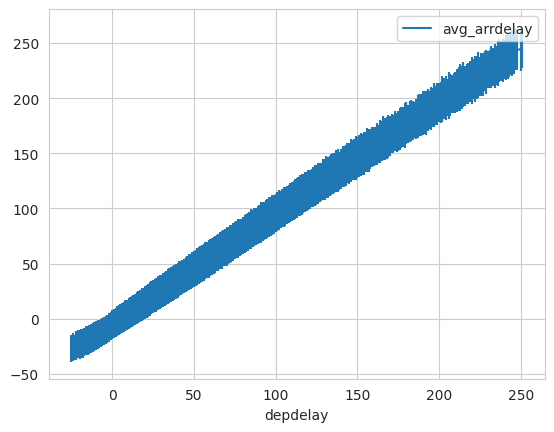

In [ ]:
df.plot(kind='line', x='depdelay', y='avg_arrdelay', yerr='std_arrdelay')

<Axes: xlabel='depdelay'>

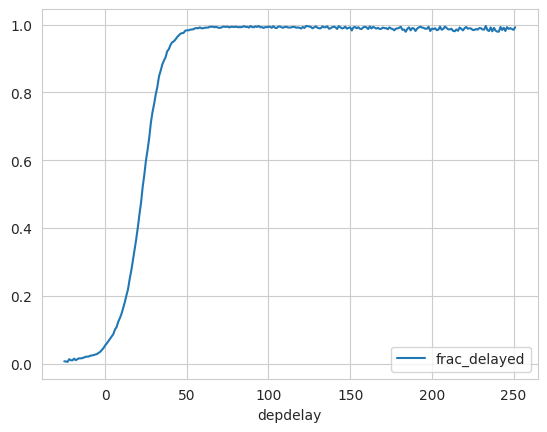

In [ ]:
df.plot(kind='line', x='depdelay', y='frac_delayed')

In [ ]:
df.head()

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights
0,251.0,244.473545,16.915317,0.992126,381
1,250.0,244.642857,20.337392,0.984375,384
2,248.0,243.685185,18.084647,0.989529,382
3,247.0,244.466495,18.529296,0.987277,393
4,246.0,243.686076,21.878708,0.992462,398


## For which departure delay, the flight is late
The frac_delayed increases as the depdelay increases. We can find a threshold of depdelay for more than 30% of delayed flights.

In [ ]:
df[(df.frac_delayed > 0.29) & (df.frac_delayed < 0.31)]

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights
233,17.0,11.714628,14.623452,0.305627,41014


## Find the decision boundary based on normal distribution assumption:
For each depdelay, there are at least 365 flights. Assume the arrival delays follow the normal distribution for each depdelay. We would like to find that for each depdelay, what is the arrival delay cutoff with the probability of 70%?   

In [ ]:
# The z-score of standard normal distribtuion at 0.7
from scipy.stats import norm

probability = 0.7
z_value = norm.ppf(probability)
print("Z-value:", z_value)

Z-value: 0.5244005127080407


For each depdelay, the mean of the arrival delay distribution is avg_arrdelay and the standard deviation of the distribution is std_arrdelay. To transform the distribution to standard normal distribution, we calcualte the z_score as:
$$
z\_score =\frac{cutoff\_arrdelay - avg\_arrdelay}{std\_arrdelay}
$$
The cutoff_arrdelay is:
$$
cutoff\_arrdelay = avg\_arrdelay + (z\_score \times std\_arrdelay)
$$

In [ ]:
# Calculate the cutoff_arrdelay for each depture delay at 70% probability
df['cutoff_arrdelay'] = df['avg_arrdelay'] + 0.52 * df['std_arrdelay']

In [ ]:
df.head()

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights,cutoff_arrdelay
0,251.0,244.473545,16.915317,0.992126,381,253.269510
1,250.0,244.642857,20.337392,0.984375,384,255.218301
2,248.0,243.685185,18.084647,0.989529,382,253.089202
3,247.0,244.466495,18.529296,0.987277,393,254.101729
4,246.0,243.686076,21.878708,0.992462,398,255.063004


## Find the departure delay at which there is more than 30% probability that the arrival delay is more than 15 minutes

In [ ]:
df[(df.cutoff_arrdelay > 14) & (df.cutoff_arrdelay < 16)]

,depdelay,avg_arrdelay,std_arrdelay,frac_delayed,num_flights,cutoff_arrdelay
236,14.0,8.484614,14.173304,0.218678,49383,15.854732
237,13.0,7.416966,14.241686,0.200439,51986,14.822643


According the above analysis, if the flight is delayed more than 13 minutes at departure, there is more than 30% chance that the flight will be late (arrival delayed more than 15 minutes.)

# Week 4 Quiz

## Evaluation
- We should verify the precision and recall of the model by using the flight data in a different year.
- We can also build model based on the origin and destination.


Now you have a simple model that make decision. Download and ingest the data for a different year (e.g., 2025) to the BigQuery. Evaluate the accuracy, precision, and recall of the decision bounarires D1 and D2:
$$
accuracy = \frac{number\_of\_correctly\_predicted\_flights}{total\_number\_of\_flights}
$$

$$
precision = \frac{number\_of\_correctly\_predicted\_delayed\_flights}{total\_number\_of\_predicted\_delayed\_flights}
$$

$$
recall = \frac{number\_of\_correctly\_predicted\_delayed\_flights}{total\_number\_of\_truly\_delayed\_flights}
$$

## Download and ingest the 2025 data.

## For 2025 data, extract the total number of flights

In [ ]:
sql = """
SELECT count(*) as total_flights
FROM `dsongcp.flights-2025`
WHERE origin IN (
  SELECT origin
  FROM `dsongcp.flights-2025`
  GROUP BY origin
  HAVING COUNT(*) >= 365
)
"""

df=bq.query(sql).to_dataframe()

In [ ]:
total_flights = int(df.values[0][0])
total_flights

6995318

### For 2025 data, extract the total number of delayed flights

In [ ]:
sql = """
SELECT count(*) as total_flights
FROM `dsongcp.flights-2025`
WHERE origin IN (
  SELECT origin
  FROM `dsongcp.flights-2025`
  GROUP BY origin
  HAVING COUNT(*) >= 365
) and ArrDelay > 15
"""

df=bq.query(sql).to_dataframe()

In [ ]:
total_delayed = int(df.values[0][0])
total_delayed

1486391

## Evaluate DepDelay > 13:

### For 2025 data, extract the total number of delayed flights given DepDelay > 13; this is the number of true positives

In [ ]:
sql = """
SELECT count(*) as total_flights
FROM `dsongcp.flights-2025`
WHERE origin IN (
  SELECT origin
  FROM `dsongcp.flights-2025`
  GROUP BY origin
  HAVING COUNT(*) >= 365
) and ArrDelay > 15 and DepDelay > 13
"""

df=bq.query(sql).to_dataframe()

In [ ]:
tp = int(df.values[0][0])
tp

1202298

### For 2025 data, the number of false negatives is the difference between the total delayed flights and the number of true postives.

In [ ]:
fn = total_delayed - tp
fn

284093

### For 2025 data, then total number of negatives are the number of on-time flights.

In [ ]:
total_ontime = total_flights - total_delayed
total_ontime

5508927

### For 2025 data, extract the total number of ontime flights given the DepDelay < 13; this is the number of true negatives.

In [ ]:
sql = """
SELECT count(*) as total_flights
FROM `dsongcp.flights-2025`
WHERE origin IN (
  SELECT origin
  FROM `dsongcp.flights-2025`
  GROUP BY origin
  HAVING COUNT(*) >= 365
) and ArrDelay < 15 and DepDelay <= 13
"""

df=bq.query(sql).to_dataframe()

In [ ]:
tn = int(df.values[0][0])
tn

5025287

### For 2025 data, the total number of false postives is the difference between the total number of ontime flights and the true negatives.

In [ ]:
fp = total_ontime - tn
fp

483640

### The evalaution metrics for DepDelay>13:

In [ ]:
accuracy = (tp+tn)/(tp+tn+fp+fn)
accuracy

0.8902504503726636

In [ ]:
precision = tp / (tp+fp)
precision

0.7131329859105139

In [ ]:
recall = tp / (tp+fn)
recall

0.808870613452315

In [ ]:
tp+fp+tn+fn, total_flights

(6995318, 6995318)

## Discussion:
- The DepDelay > 13 rule gives higher recall but lower precision.
- If DepDelay > 13, then cancel the meeting. It may result in the situation that the flight would actually be on-time.
- For more relax situations, only if DepDelay > 17, then cancel the meeting. It may result in the situation that the flight would actually be late.